## orflib Library Examples

In [7]:
import orflib as orf
import numpy as np
import os
import matplotlib.pyplot as plt
plt.style.use('ggplot')

print("orflib version: {0}".format(orf.version()))
print("pid: {0}".format(os.getpid()))

orflib version: 0.9.0-debug
pid: 3118


# Q2

In [8]:
ycname = "USD"
yc = orf.ycCreate(ycname = ycname, 
                  tmats = [2], 
                  vals =  [0.04],
                  valtype = 0)
PDE = dict()
PDE["NTIMESTEPS"] = 800
PDE["NSPOTNODES"] = 800
PDE["NSTDDEVS"] = 5
PDE["THETA"] = 0.5
price_berm_put = orf.bermBSPDE(-1, 100.0, [0.25,0.5,0.75,1.00], 100.0, "USD", 0.0, 0.4, PDE, False)['Price']
price_euro_put = orf.euroBSPDE(-1, 100.0, 1, 100.0, "USD", 0.0, 0.4, PDE, False)['Price']
price_amer_put = orf.amerBSPDE(-1, 100.0, 1, 100.0, "USD", 0.0, 0.4, PDE, False)['Price']

price_berm_call = orf.bermBSPDE(1, 100.0, [0.25,0.5,0.75,1.00], 100.0, "USD", 0.0, 0.4, PDE, False)['Price']
price_euro_call = orf.euroBSPDE(1, 100.0, 1, 100.0, "USD", 0.0, 0.4, PDE, False)['Price']
price_amer_call = orf.amerBSPDE(1, 100.0, 1, 100.0, "USD", 0.0, 0.4, PDE, False)['Price']

In [ ]:
print(f'The Bermuda Call Price is: {price_berm_call} and this is bounded as follows')
print(f'Lower bound: European Call Price: {price_euro_call}')
print(f'Upper Bound: American Call Price: {price_amer_call}')

print(f'\nThe Bermuda Put Price is: {price_berm_put} and this is bounded as follows')
print(f'Lower bound: European Put Price: {price_euro_put}')
print(f'Upper Bound: American Put Price: {price_amer_put}')

print("\n Without dividends, there is no point exercising early on a Call option, hence the prices of the European, American and Bermuda Call options are the same.")
print(" However, for Put options, early exercise can be optimal, hence the American Put is more expensive than the European Put, and the Bermuda Put lies in between.")


The Bermuda Call Price is: 17.577985353165573 and this is bounded as follows
Lower bound: European Call Price: 17.57798535316557
Upper Bound: American Call Price: 17.577985501592018
The Bermuda Put Price is: 13.93088831576159 and this is bounded as follows
Lower bound: European Put Price: 13.656929268393265
Upper Bound: American Put Price: 14.055256254267341


In [13]:
price_berm_put = orf.bermBSPDE(-1, 100.0, [0.25,0.5,0.75,1.00], 100.0, "USD", 0.03, 0.4, PDE, False)['Price']
price_euro_put = orf.euroBSPDE(-1, 100.0, 1, 100.0, "USD", 0.03, 0.4, PDE, False)['Price']
price_amer_put = orf.amerBSPDE(-1, 100.0, 1, 100.0, "USD", 0.03, 0.4, PDE, False)['Price']

price_berm_call = orf.bermBSPDE(1, 100.0, [0.25,0.5,0.75,1.00], 100.0, "USD", 0.03, 0.4, PDE, False)['Price']
price_euro_call = orf.euroBSPDE(1, 100.0, 1, 100.0, "USD", 0.03, 0.4, PDE, False)['Price']
price_amer_call = orf.amerBSPDE(1, 100.0, 1, 100.0, "USD", 0.03, 0.4, PDE, False)['Price']

In [21]:
print(f'The Bermuda Call Price is: {price_berm_call} and this is bounded as follows')
print(f'Lower bound: European Call Price: {price_euro_call}')
print(f'Upper Bound: American Call Price: {price_amer_call}')

print(f'\nThe Bermuda Put Price is: {price_berm_put} and this is bounded as follows')
print(f'Lower bound: European Put Price: {price_euro_put}')
print(f'Upper Bound: American Put Price: {price_amer_put}')

print("\nWith dividends, the Call option prices differ as well. Early exercise can be optimal for Call options when dividends are present.")
print("Hence, the American Call is more expensive than the European Call, and the Bermuda Call lies in between.")
print("However, here the gap in the put valuations is less pronounced compared to the no-dividend case. This is because the presence of dividends reduces the incentive to exercise early on Put options.")
print("Note that, while the differences in price decrease with dividends, the overall price of the same put option increases due to the dividends lowering the expected future stock price.")

The Bermuda Call Price is: 15.825811038319546 and this is bounded as follows
Lower bound: European Call Price: 15.794118460251006
Upper Bound: American Call Price: 15.841465955643224

The Bermuda Put Price is: 14.955176947186978 and this is bounded as follows
Lower bound: European Put Price: 14.828509020638602
Upper Bound: American Put Price: 15.019361870508154

With dividends, the Call option prices differ as well. Early exercise can be optimal for Call options when dividends are present.
Hence, the American Call is more expensive than the European Call, and the Bermuda Call lies in between.
However, here the gap in the put valuations is less pronounced compared to the no-dividend case. This is because the presence of dividends reduces the incentive to exercise early on Put options.
Note that, while the differences in price decrease with dividends, the overall price of the same put option increases due to the dividends lowering the expected future stock price.


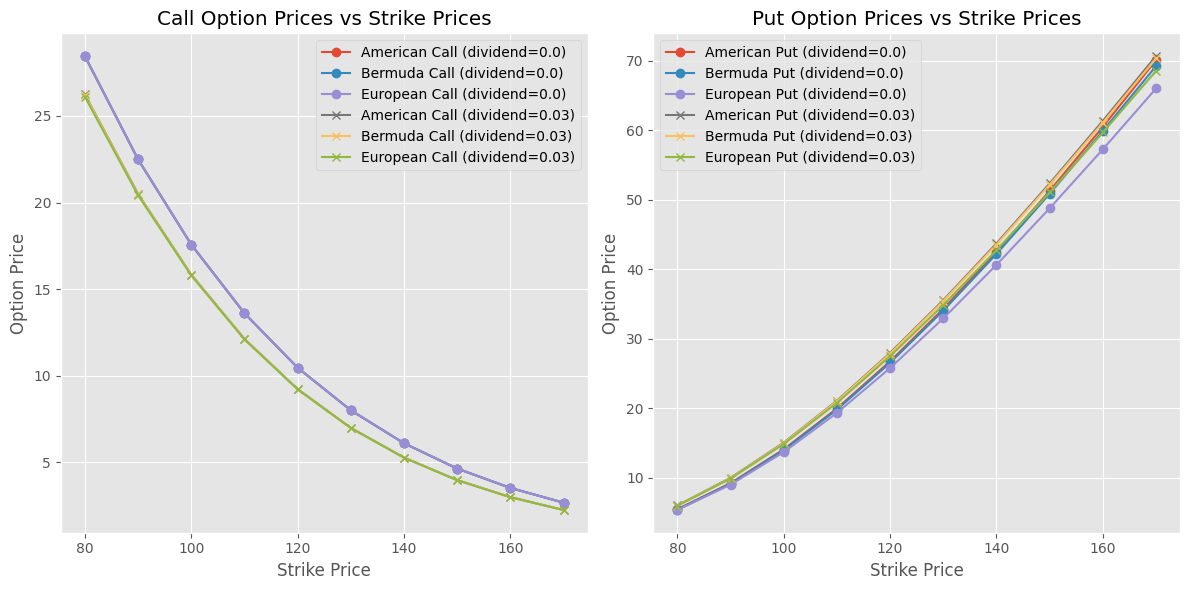

In [24]:
price_amer_calls = []
price_berm_calls = []
price_euro_calls = []

price_amer_puts = []
price_berm_puts = []
price_euro_puts = []
strikes = [80, 90, 100, 110, 120, 130, 140, 150, 160, 170]

for dividend_yield in [0.0, 0.03]:
    for strike in strikes:
        price_amer_calls.append(orf.amerBSPDE(1, strike, 1, 100.0, "USD", dividend_yield, 0.4, PDE, False)['Price'])
        price_berm_calls.append(orf.bermBSPDE(1, strike, [0.25,0.5,0.75,1.00], 100.0, "USD", dividend_yield, 0.4, PDE, False)['Price'])
        price_euro_calls.append(orf.euroBSPDE(1, strike, 1, 100.0, "USD", dividend_yield, 0.4, PDE, False)['Price'])

        price_amer_puts.append(orf.amerBSPDE(-1, strike, 1, 100.0, "USD", dividend_yield, 0.4, PDE, False)['Price'])
        price_berm_puts.append(orf.bermBSPDE(-1, strike, [0.25,0.5,0.75,1.00], 100.0, "USD", dividend_yield, 0.4, PDE, False)['Price'])
        price_euro_puts.append(orf.euroBSPDE(-1, strike, 1, 100.0, "USD", dividend_yield, 0.4, PDE, False)['Price'])

# Plotting Call Prices
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
plt.plot(strikes, price_amer_calls[0:10], label='American Call (dividend=0.0)', marker='o')
plt.plot(strikes, price_berm_calls[0:10], label='Bermuda Call (dividend=0.0)', marker='o')
plt.plot(strikes, price_euro_calls[0:10], label='European Call (dividend=0.0)', marker='o')
plt.plot(strikes, price_amer_calls[10:20], label='American Call (dividend=0.03)', marker='x')
plt.plot(strikes, price_berm_calls[10:20], label='Bermuda Call (dividend=0.03)', marker='x')
plt.plot(strikes, price_euro_calls[10:20], label='European Call (dividend=0.03)', marker='x')
plt.title('Call Option Prices vs Strike Prices')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)

# Plotting Put Prices
plt.subplot(1,2,2)          
plt.plot(strikes, price_amer_puts[0:10], label='American Put (dividend=0.0)', marker='o')
plt.plot(strikes, price_berm_puts[0:10], label='Bermuda Put (dividend=0.0)', marker='o')
plt.plot(strikes, price_euro_puts[0:10], label='European Put (dividend=0.0)', marker='o')
plt.plot(strikes, price_amer_puts[10:20], label='American Put (dividend=0.03)', marker='x')
plt.plot(strikes, price_berm_puts[10:20], label='Bermuda Put (dividend=0.03)', marker='x')
plt.plot(strikes, price_euro_puts[10:20], label='European Put (dividend=0.03)', marker='x')
plt.title('Put Option Prices vs Strike Prices')
plt.xlabel('Strike Price')
plt.ylabel('Option Price')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
